# Missing Values dan Normalisasi Data

## Missing Values
## A. Pengertian Missing Value Imputation

Missing value imputation adalah proses mengisi data yang hilang dalam dataset dengan nilai perkiraan yang logis. Tujuan imputasi adalah mengurangi bias dan memastikan analisis data dapat berjalan dengan lebih akurat. Tanpa imputasi, data yang hilang dapat menyebabkan kesalahan perhitungan, analisis statistik yang tidak valid, atau model prediksi yang kurang tepat.

## B. Metode Weighted K-Nearest Neighbor (WKNN)
WKNN adalah pengembangan dari metode K-Nearest Neighbor (KNN) yang menambahkan konsep bobot pada setiap tetangga terdekat.  

Inti dari metode ini adalah:
- Tetangga yang lebih dekat ke data dengan nilai hilang akan memberikan pengaruh lebih besar.
- Tetangga yang lebih jauh akan berkontribusi lebih kecil.

Tahapan WKNN:
1. Tentukan data yang memiliki nilai hilang.
2. Identifikasi tetangga potensial yang memiliki data lengkap.
3. Ukur kedekatan antara data hilang dengan tetangga menggunakan jarak tertentu.
4. Pilih sejumlah tetangga terdekat.
5. Berikan bobot pada masing-masing tetangga sesuai kedekatannya.
6. Hitung nilai perkiraan untuk data yang hilang berdasarkan kontribusi tetangga dengan bobot.

Dengan cara ini, nilai yang hilang dapat diimputasi secara lebih realistis dan sesuai pola data yang ada.


## C. Imputasi Missing Value Menggunakan Microsoft Excel
WKNN juga dapat diterapkan secara manual di Excel. Langkah-langkahnya antara lain:

1. Catat data lengkap dan data yang memiliki nilai hilang di worksheet.
2. Hitung jarak antar data menggunakan rumus Euclidean atau metode jarak lain.
3. Pilih beberapa tetangga terdekat dari data hilang.
4. Tentukan bobot tiap tetangga berdasarkan jaraknya; tetangga lebih dekat mendapatkan bobot lebih tinggi.
5. Kalikan bobot dengan nilai atribut masing-masing tetangga.
6. Jumlahkan hasil perkalian bobot × atribut dan total bobot.
7. Hitung nilai imputasi dengan membagi jumlah bobot × atribut dengan total bobot.
8. Masukkan nilai hasil imputasi ke sel yang awalnya kosong.



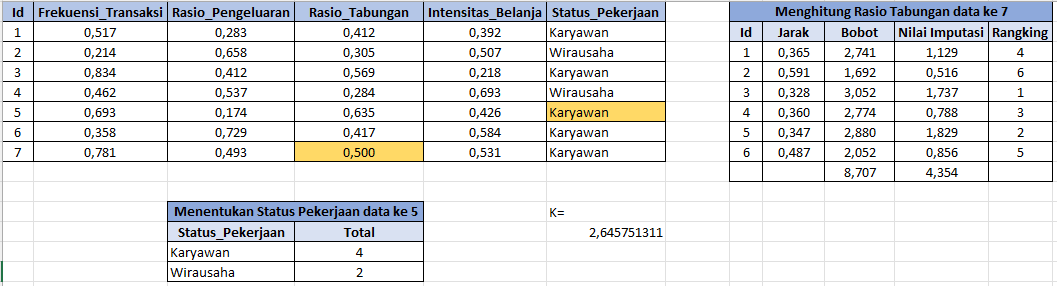

## D. Imputasi Missing Value Menggunakan Microsoft Excel

### 1. Persiapan Library dan Dataset
Tahap pertama adalah menyiapkan library yang diperlukan serta membuat dataset yang akan digunakan untuk analisis dan perhitungan.

Dataset ini memiliki beberapa atribut numerik, yaitu:
Frekuensi_Transaksi
- Rasio_Pengeluaran
- Rasio_Tabungan
- Intensitas_Belanja

Selain itu, terdapat satu atribut kategorikal:
- Status_Pekerjaan

Dalam dataset ini terdapat beberapa data yang hilang atau tidak diketahui, antara lain:
- Nilai Rasio_Tabungan pada baris ke-7
- Status pekerjaan pada baris ke-5 ditandai dengan simbol "?"

Data yang hilang tersebut nantinya akan diisi melalui metode imputasi berbasis tetangga terdekat (WKNN) agar analisis berikutnya bisa berjalan dengan lengkap dan akurat.

In [22]:
import pandas as pd
import numpy as np

data = {
    "ID": [1,2,3,4,5,6,7],
    "Frekuensi_Transaksi": [0.517, 0.214, 0.834, 0.462, 0.693, 0.358, 0.781],
    "Rasio_Pengeluaran": [0.283, 0.658, 0.412, 0.537, 0.174, 0.729, 0.493],
    "Rasio_Tabungan": [0.412, 0.305, 0.569, 0.284, 0.635, 0.417, np.nan],
    "Intensitas_Belanja": [0.392, 0.507, 0.218, 0.693, 0.426, 0.584, 0.531],
    "Status_Pekerjaan": ["Karyawan", "Wirausaha", "Karyawan", "Wirausaha", "?", "Karyawan", "Karyawan"]
}

df = pd.DataFrame(data)
df

,ID,Frekuensi_Transaksi,Rasio_Pengeluaran,Rasio_Tabungan,Intensitas_Belanja,Status_Pekerjaan
0,1,0.517,0.283,0.412,0.392,Karyawan
1,2,0.214,0.658,0.305,0.507,Wirausaha
2,3,0.834,0.412,0.569,0.218,Karyawan
3,4,0.462,0.537,0.284,0.693,Wirausaha
4,5,0.693,0.174,0.635,0.426,?
5,6,0.358,0.729,0.417,0.584,Karyawan
6,7,0.781,0.493,NaN,0.531,Karyawan


**Penjelasan Code**
- import pandas as pd : Mengimpor library pandas dengan alias pd.
- import numpy as np : Mengimpor library numpy dengan alias np, digunakan untuk np.nan.
- data = {...} : Membuat dictionary Python yang berisi nama kolom dan daftar nilainya.
- np.nan : Menandai missing value di Rasio_Tabungan baris ke-7.
- df = pd.DataFrame(data) : Mengubah dictionary menjadi DataFrame agar mudah dianalisis.

### 2. Menghitung Jarak Euclidean

Langkah ini menghitung jarak antara data target (baris ke-7) dengan setiap tetangga (baris 1–6) menggunakan **Euclidean Distance**:

$$
d = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2 + (x_3 - y_3)^2}
$$

di mana:  
- $x_1, x_2, x_3$ : nilai atribut target (Frekuensi_Transaksi, Rasio_Pengeluaran, Intensitas_Belanja)  
- $y_1, y_2, y_3$ : nilai atribut tiap tetangga  


In [23]:
target = df.loc[6, ['Frekuensi_Transaksi','Rasio_Pengeluaran','Intensitas_Belanja']]

jarak = []
for i in range(6):
    data_row = df.loc[i, ['Frekuensi_Transaksi','Rasio_Pengeluaran','Intensitas_Belanja']]
    dist = np.sqrt(
        (target['Frekuensi_Transaksi'] - data_row['Frekuensi_Transaksi'])**2 +
        (target['Rasio_Pengeluaran'] - data_row['Rasio_Pengeluaran'])**2 +
        (target['Intensitas_Belanja'] - data_row['Intensitas_Belanja'])**2
    )
    jarak.append(dist)

df_jarak = df.iloc[:6].copy()
df_jarak['Jarak'] = jarak
df_jarak[['ID','Jarak']].round(3)

,ID,Jarak
0,1,0.365
1,2,0.591
2,3,0.328
3,4,0.360
4,5,0.347
5,6,0.487


**Penjelasan Code**
- target = df.loc[6, [...]] : Mengambil baris ke-7 sebagai data target, hanya atribut numerik yang relevan.  
- jarak = [] : List kosong untuk menampung jarak Euclidean tiap baris.  
- for i in range(6): : Loop untuk menghitung jarak ke 6 baris pertama.  
- data_row = df.loc[i, [...]] : Mengambil baris i dari DataFrame.  
- dist = np.sqrt(...) : Menghitung jarak Euclidean antara target dan baris i.  
- jarak.append(dist) : Menyimpan jarak ke list jarak.  
- df_jarak = df.iloc[:6].copy() : Membuat salinan 6 baris pertama untuk ditambahkan kolom jarak.  
- df_jarak['Jarak'] = jarak : Menambahkan kolom jarak hasil perhitungan.  
- df_jarak[['ID','Jarak']].round(3) : Menampilkan tabel, hanya kolom ID dan Jarak, dibulatkan 3 desimal.

### 3. Menghitung Bobot WKNN

Setelah jarak Euclidean dihitung, setiap tetangga diberikan **bobot** berdasarkan kedekatannya dengan data target.  

Rumus bobot yang digunakan adalah:

$$
w_i = \frac{1}{d_i}
$$

di mana:  
- $w_i$ → bobot tetangga ke-$i$  
- $d_i$ → jarak Euclidean antara data target dan tetangga ke-$i$  

Semakin kecil jarak, semakin besar bobotnya, sehingga tetangga yang lebih dekat memiliki pengaruh lebih besar pada imputasi nilai yang hilang.

In [24]:
df_jarak['Bobot'] = 1 / df_jarak['Jarak']
df_jarak[['ID','Jarak','Bobot']].round(3)

,ID,Jarak,Bobot
0,1,0.365,2.741
1,2,0.591,1.692
2,3,0.328,3.052
3,4,0.360,2.774
4,5,0.347,2.880
5,6,0.487,2.052


**Penjelasan Code**
- df_jarak['Bobot'] = 1 / df_jarak['Jarak']  
  - Menghitung bobot untuk setiap tetangga berdasarkan jarak Euclidean.  
  - Semakin kecil jarak, semakin besar bobotnya.  
- df_jarak[['ID','Jarak','Bobot']].round(3)
  - Menampilkan DataFrame hanya dengan kolom ID, Jarak, dan Bobot.  
  - round(3) digunakan agar angka ditampilkan dengan 3 desimal.

### 4. Menghitung Nilai Imputasi
Langkah ini menghitung kontribusi setiap tetangga terhadap imputasi nilai yang hilang dengan cara **mengalikan bobot tetangga dengan nilai atribut** yang ingin diimputasi.  

Rumus yang digunakan:

$$
w_i \times x_i
$$

di mana:  
- $w_i$ : bobot tetangga ke-$i$  
- $x_i$ : nilai atribut tetangga ke-$i$ (dalam hal ini Rasio_Tabungan)

In [25]:
df_jarak['Bobot_x_Nilai'] = df_jarak['Bobot'] * df_jarak['Rasio_Tabungan']
df_jarak[['ID','Bobot','Rasio_Tabungan','Bobot_x_Nilai']].round(3)

,ID,Bobot,Rasio_Tabungan,Bobot_x_Nilai
0,1,2.741,0.412,1.129
1,2,1.692,0.305,0.516
2,3,3.052,0.569,1.737
3,4,2.774,0.284,0.788
4,5,2.880,0.635,1.829
5,6,2.052,0.417,0.856


**Penjelasan Code**
- df_jarak['Bobot_x_Nilai'] = df_jarak['Bobot'] * df_jarak['Rasio_Tabungan']
  - Mengalikan bobot masing-masing tetangga dengan nilai Rasio_Tabungan mereka.  
  - Hasilnya menunjukkan kontribusi berbobot tiap tetangga terhadap imputasi.  
- df_jarak[['ID','Bobot','Rasio_Tabungan','Bobot_x_Nilai']].round(3)  
  - Menampilkan tabel rapi dengan kolom penting untuk analisis: ID, Bobot, Rasio_Tabungan, dan Bobot_x_Nilai.  
  - round(3) digunakan agar angka ditampilkan 3 desimal.

### 5. Melakukan Perangkingan dan Dipilih 3 Terbesar

Langkah ini memilih k tetangga terdekat dari data target berdasarkan jarak Euclidean.  
Tetangga ini nantinya digunakan untuk menghitung nilai imputasi berbobot.

Rumus menentukan K (jumlah tetangga terdekat) bisa menggunakan pendekatan:  

$$
K = \sqrt{n}
$$

di mana:  
- $n$ : jumlah total data (tanpa data target)  
- $K$ : jumlah tetangga yang dipilih (dibulatkan ke bilangan bulat terdekat)   

Setelah K ditentukan, DataFrame diurutkan berdasarkan jarak terkecil, dan **top-K baris** dipilih sebagai tetangga terdekat.

In [31]:
k = 3
tetangga = df_jarak.sort_values(by='Jarak').head(k)
tetangga[['ID','Jarak','Bobot','Rasio_Tabungan']].round(3)

,ID,Jarak,Bobot,Rasio_Tabungan
2,3,0.328,3.052,0.569
4,5,0.347,2.880,0.635
3,4,0.360,2.774,0.284


**Penjelasan Code**
- k = 3  
  - Menentukan jumlah tetangga terdekat yang akan digunakan.  
  - Bisa disesuaikan, misalnya $\sqrt{n}$ atau hasil eksperimen.
- df_jarak.sort_values(by='Jarak').head(k)
  - Mengurutkan DataFrame berdasarkan kolom Jarak dari yang terkecil ke terbesar.  
  - head(k) mengambil k baris pertama, yaitu tetangga terdekat.
- tetangga[['ID','Jarak','Bobot','Rasio_Tabungan']]`
  - Menampilkan kolom penting: ID, jarak, bobot, dan nilai atribut (Rasio_Tabungan) tetangga.

### 6. Menentukan Nilai yang Hilang
Setelah diperoleh 3 tetangga dengan bobot terbesar, langkah berikutnya adalah menghitung nilai imputasi untuk Rasio_Tabungan.

Rumus digunakan:

$$
\hat{x} = \frac{\sum_{i=1}^{K} w_i \cdot x_i}{\sum_{i=1}^{K} w_i}
$$

di mana:  
- $\hat{x}$ : nilai imputasi prediksi untuk data target  
- $w_i$ : bobot tetangga ke-$i$  
- $x_i$ : nilai atribut tetangga ke-$i$ (Rasio_Tabungan)  
- $K$ : jumlah tetangga terdekat  

Hasil perhitungan ini merupakan prediksi nilai Rasio_Tabungan untuk baris ke-7.

In [27]:
prediksi = tetangga['Bobot_x_Nilai'].sum() / tetangga['Bobot'].sum()
print("Prediksi Rasio Tabungan data ke-7:", round(prediksi,3))

Prediksi Rasio Tabungan data ke-7: 0.5


**Penjelasan Code**
- tetangga['Bobot_x_Nilai'].sum() : Menjumlahkan semua nilai Bobot × Rasio_Tabungan dari k tetangga terdekat.  
- tetangga['Bobot'].sum() : Menjumlahkan semua bobot dari k tetangga terdekat.  
- prediksi = ... : Membagi total Bobot × Nilai dengan total bobot untuk mendapatkan rata-rata berbobot.  
- round(prediksi, 3) : Membulatkan hasil prediksi menjadi 3 desimal agar lebih mudah dibaca.

### 7. Imputasi Data Kategorikal Menggunakan Modus

Dataset ini tidak hanya berisi data numerik, tetapi juga data kategorikal seperti Status_Pekerjaan.  
Pada dataset ini terdapat nilai yang hilang atau tidak jelas pada baris ke-5.  

Untuk mengisi missing value pada data kategorikal, metode yang digunakan adalah modus, yaitu kategori yang paling sering muncul pada kolom tersebut.  

Rumus modus dapat dituliskan secara sederhana sebagai:

$$
\text{modus}(x) = \underset{v \in X}{\mathrm{arg\,max}}\, f(v)
$$

di mana:  
- $X$ : semua nilai unik pada kolom  
- $f(v)$ : frekuensi kemunculan nilai $v$  

Nilai dengan frekuensi tertinggi inilah yang dipakai untuk menggantikan data yang hilang.

In [28]:
status_count = df["Status_Pekerjaan"].value_counts()

print("Jumlah Status:")
print(status_count)

Jumlah Status:
Status_Pekerjaan
Karyawan     4
Wirausaha    2
?            1
Name: count, dtype: int64


**Penjelasan Kode**

- df["Status_Pekerjaan"].value_counts() : Menghitung jumlah kemunculan masing-masing kategori dalam kolom Status_Pekerjaan.  
- print("Jumlah Status:") : Menampilkan keterangan sebelum hasil tabel.  
- print(status_count) : Menampilkan tabel jumlah kategori, yang membantu menentukan modus untuk imputasi.

### 8. Tampilan Data Akhir
Pada hail akhir:
- nilai Rasio_Tabungan pada data ke-7 sudah terisi menggunakan metode WKNN
- nilai Status_Pekerjaan pada data ke-5 sudah terisi menggunakan metode modus

In [33]:
df.loc[6, 'Rasio_Tabungan'] = prediksi

modus_status = df['Status_Pekerjaan'].mode()[0]
df.loc[4, 'Status_Pekerjaan'] = modus_status

df.round(3)

,ID,Frekuensi_Transaksi,Rasio_Pengeluaran,Rasio_Tabungan,Intensitas_Belanja,Status_Pekerjaan
0,1,0.517,0.283,0.412,0.392,Karyawan
1,2,0.214,0.658,0.305,0.507,Wirausaha
2,3,0.834,0.412,0.569,0.218,Karyawan
3,4,0.462,0.537,0.284,0.693,Wirausaha
4,5,0.693,0.174,0.635,0.426,Karyawan
5,6,0.358,0.729,0.417,0.584,Karyawan
6,7,0.781,0.493,0.500,0.531,Karyawan


**Penjelasan Kode**
- df.loc[6, 'Rasio_Tabungan'] = prediksi : Mengisi missing value numerik (Rasio_Tabungan) pada baris ke-7 dengan prediksi WKNN.
- modus_status = df['Status_Pekerjaan'].mode()[0] : Menentukan nilai modus dari kolom Status_Pekerjaan sebagai pengganti missing value.
- df.loc[4, 'Status_Pekerjaan'] = modus_status : Mengisi missing value kategorikal pada baris ke-5 dengan modus.
- df.round(3) : Menampilkan seluruh DataFrame rapi dengan angka numerik dibulatkan 3 desimal.

## Normalisasi Data
## A. Pengertian Normalisasi Data
Normalisasi data adalah proses mengubah nilai suatu data ke dalam rentang tertentu agar skala datanya lebih seragam, namun tetap mempertahankan makna atau informasi penting yang ada dalam data tersebut. Tujuan utama dari normalisasi adalah agar setiap atribut atau variabel memiliki skala yang seimbang sehingga tidak ada atribut yang mendominasi perhitungan ketika digunakan dalam proses analisis data atau pembelajaran mesin.

Dalam proses menganalisis data, terutama di bidang Data Mining dan Machine Learning, banyak algoritma tergantung pada skala data dan bisa terpengaruh jika ada perbedaan skala yang besar. Jika suatu atribut memiliki nilai yang sangat besar dibandingkan atribut lainnya, algoritma bisa memberikan bobot yang tidak seimbang pada atribut tersebut. Oleh karena itu, normalisasi dibutuhkan agar semua data memiliki skala yang sama, sehingga proses analisis menjadi lebih stabil, akurat, dan efisien.


## B. Macam-macam Normalisasi Data
Beberapa metode normalisasi yang sering digunakan dalam pengolahan data antara lain Min-Max Normalization, Z-Score Normalization, dan Max Absolute Scaling.

### 1. Min-Max Normalization

Min-Max Normalization merupakan metode normalisasi yang mengubah nilai data ke dalam rentang tertentu yang telah ditentukan. Biasanya rentang yang digunakan adalah 0 sampai 1, tetapi metode ini juga dapat digunakan untuk mengubah data ke rentang lain sesuai kebutuhan. Metode ini bekerja dengan cara mengurangi nilai data dengan nilai minimum dari atribut tersebut, kemudian membaginya dengan selisih antara nilai maksimum dan nilai minimum.

Rumus:

$
v' = \frac{v - \min(A)}{\max(A) - \min(A)} \times (new_{max} - new_{min}) + new_{min}
$

Keterangan:

- $v$ : nilai data asli  
- $v'$ : nilai data setelah normalisasi  
- $\min(A)$ : nilai minimum dari atribut $A$  
- $\max(A)$ : nilai maksimum dari atribut $A$  
- $new_{min}$ : batas minimum dari rentang baru  
- $new_{max}$ : batas maksimum dari rentang baru





#### Contoh:
| Data Asli |
| --------- |
| 10        |
| 20        |
| 30        |
| 40        |

Nilai minimum = 10

Nilai maksimum = 40

| Data Asli | Hasil Normalisasi |
| --------- | ----------------- |
| 10        | 0                 |
| 20        | 0.3               |
| 30        | 0.7               |
| 40        | 1                 |

#### Implementasi Normalisasi Menggunakan Python

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

data = pd.DataFrame({
    'Jam_Belajar': [2, 4, 6, 8],
    'Nilai_Ujian': [60, 70, 80, 90]
})

print("Data sebelum normalisasi:")
print(data)

scaler = MinMaxScaler()

hasil = scaler.fit_transform(data)

data_normalized = pd.DataFrame(hasil, columns=data.columns).round(1)

print("\nData setelah normalisasi:")
print(data_normalized)

Data sebelum normalisasi:
   Jam_Belajar  Nilai_Ujian
0            2           60
1            4           70
2            6           80
3            8           90

Data setelah normalisasi:
   Jam_Belajar  Nilai_Ujian
0          0.0          0.0
1          0.3          0.3
2          0.7          0.7
3          1.0          1.0


**enjelasan Kode**
- MinMaxScaler() : Mengubah data numerik ke skala 0–1
- fit_transform(data) : Mempelajari nilai min & max tiap kolom, lalu menormalisasi.  
- pd.DataFrame(..., columns=data.columns).round(1) : Mengubah hasil menjadi DataFrame rapi dengan 1 desimal.  
- print() : Menampilkan data sebelum dan sesudah normalisasi.

### 2. Z-Score Normalization

Z-Score Normalization merupakan metode normalisasi yang mengubah nilai data berdasarkan rata-rata dan standar deviasi dari atribut tersebut. Metode ini digunakan untuk mengukur seberapa jauh suatu nilai dari rata-rata dataset dalam satuan standar deviasi.

Rumus Z-Score Normalization:

$
v' = \frac{v - \mu}{\sigma}
$

Keterangan:

- $v$ = nilai asli  
- $v'$ = nilai setelah normalisasi  
- $\mu$ = rata-rata (mean) atribut  
- $\sigma$ = standar deviasi  

Setelah proses normalisasi dilakukan:

- rata-rata data menjadi **0**
- standar deviasi menjadi **1**

#### Rumus Mean

$
\mu = \frac{1}{n} \sum_{i=1}^{n} v_i
$

Keterangan:

- $\mu$ = rata-rata data  
- $n$ = jumlah data  
- $v_i$ = nilai data ke-$i$

#### Rumus Standar Deviasi

$
\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (v_i - \mu)^2}
$

Keterangan:

- $\sigma$ = standar deviasi  
- $n$ = jumlah data  
- $v_i$ = nilai data ke-$i$  
- $\mu$ = rata-rata data

#### Contoh:
| Data Asli |
| --------- |
| 2         |
| 4         |
| 6         |
| 8         |

$
\mu = \frac{2+4+6+8}{4}
$

$
\mu = 5 (mean)
$

$
\sigma = \sqrt{\frac{(2-5)^2+(4-5)^2+(6-5)^2+(8-5)^2}{4}}
$

$
\sigma = \sqrt{\frac{9+1+1+9}{4}}
$

$
\sigma = \sqrt{5}
$

$
\sigma = 2.24 (Standar Deviasi)
$

| Data Asli | Hasil Normalisasi |
| --------- | ----------------- |
| 2         | -1.3              |
| 4         | -0.4              |
| 6         | 0.4               |
| 8         | 1.3               |

#### Implementasi Normalisasi Menggunakan Python


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

data = pd.DataFrame({
    'Jam_Kerja': [5, 7, 9, 11],
    'Penjualan': [100, 150, 200, 250]
})

print("Data sebelum normalisasi:")
print(data)

print("\nMean tiap kolom:")
print(data.mean())

print("\nStandar deviasi tiap kolom:")
print(data.std().round(2))

scaler = StandardScaler()
hasil = scaler.fit_transform(data)

data_zscore = pd.DataFrame(hasil, columns=data.columns).round(2)

print("\nData setelah Z-Score Normalization:")
print(data_zscore)

Data sebelum normalisasi:
   Jam_Kerja  Penjualan
0          5        100
1          7        150
2          9        200
3         11        250

Mean tiap kolom:
Jam_Kerja      8.0
Penjualan    175.0
dtype: float64

Standar deviasi tiap kolom:
Jam_Kerja     2.58
Penjualan    64.55
dtype: float64

Data setelah Z-Score Normalization:
   Jam_Kerja  Penjualan
0      -1.34      -1.34
1      -0.45      -0.45
2       0.45       0.45
3       1.34       1.34


**Penjelasan Kode**
- StandardScaler() : Membuat objek untuk normalisasi Z-Score, yang mengubah data sehingga memiliki mean = 0 dan standar deviasi = 1.
- fit_transform(data) : Menghitung mean & std tiap kolom, lalu menormalisasi semua nilai ke Z-Score.
- pd.DataFrame(..., columns=data.columns).round(2) : Mengubah hasil array menjadi DataFrame rapi dengan 2 desimal.
- print(data.mean()) & print(data.std().round(2)) : Menampilkan mean dan standar deviasi sebelum normalisasi untuk pengecekan.
- print(data_zscore) : Menampilkan data setelah Z-Score Normalization, siap digunakan untuk analisis atau machine learning.

### 3. Decimal Scaling Normalization

Decimal Scaling Normalization adalah metode normalisasi yang dilakukan dengan cara menggeser posisi desimal dari setiap nilai data. Proses ini dilakukan dengan membagi nilai data dengan $10^j$ sehingga seluruh nilai berada pada rentang yang lebih kecil dari 1.

Rumus Decimal Scaling:

$
v' = \frac{v}{10^j}
$

Keterangan:

- $v$ : nilai data sebelum dilakukan normalisasi  
- $v'$ : nilai data setelah proses normalisasi  
- $j$ : bilangan bulat yang menunjukkan jumlah pergeseran desimal yang diperlukan agar nilai terbesar pada dataset menjadi kurang dari 1

#### Contoh:
| Data Asli |
| --------- |
| 250       |
| 670       |
| 890       |
| 540       |

Nilai maksimum = 890

Jumlah digit nilai maksimum = 3

Sehingga nilai j = 3

| Data Asli | Hasil Normalisasi |
| --------- | ----------------- |
| 250       | 0.25              |
| 670       | 0.67              |
| 890       | 0.89              |
| 540       | 0.54              |

#### Implementasi Normalisasi Menggunakan Python

In [ ]:
import pandas as pd
import numpy as np

data = pd.Series([180, 320, 760, 150])

def decimal_normalize(values):
    max_value = values.abs().max()

    # menghitung jumlah digit dari nilai maksimum
    j = int(np.log10(max_value)) + 1

    normalized = values / (10 ** j)

    return normalized

hasil_normalisasi = decimal_normalize(data).round(2)

print("Data sebelum normalisasi:")
print(data)

print("\nData setelah Decimal Scaling:")
print(hasil_normalisasi)

Data sebelum normalisasi:
0    180
1    320
2    760
3    150
dtype: int64

Data setelah Decimal Scaling:
0    0.18
1    0.32
2    0.76
3    0.15
dtype: float64


**Penjelasan Kode**
- max_value = values.abs().max() : Menentukan nilai maksimum mutlak dalam dataset.  
- j = int(np.log10(max_value)) + 1 : Menghitung jumlah digit dari nilai maksimum, sebagai pangkat pembagi.  
- normalized = values / (10 ** j) : Membagi setiap nilai dengan $10^j$ untuk menormalkan data.  
- hasil_normalisasi = decimal_normalize(data).round(2) : Menyimpan hasil normalisasi dan membulatkan menjadi 2 desimal.  
- print() : Menampilkan data sebelum dan sesudah normalisasi.